# FBS Detection using CNN (1D Convolutional Neural Network)

This notebook implements a 1D CNN model for False Base Station detection using sliding window sequences.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.export import export

In [2]:
normal_df = pd.read_csv('../dataset/clean/normal_dataset.csv')
attack_df = pd.read_csv('../dataset/clean/attack_dataset.csv')

In [3]:
dataset = pd.concat([normal_df, attack_df], ignore_index=True)
print(f"Total samples: {len(dataset)}")
print(f"Normal samples: {len(normal_df)}")
print(f"Attack samples: {len(attack_df)}")

Total samples: 7351
Normal samples: 819
Attack samples: 6532


In [4]:
# Separate features and labels
X = dataset.drop(columns=["label"]).values
y = dataset["label"].values

In [5]:
# ==========================================
# Step 2 — Keep -1 mask BEFORE normalization
# ==========================================
mask = (X == -1)   # True where feature value is -1 (unused)

In [6]:
def create_sliding_windows(X, y, window_size=10):
    X_seq = []
    y_seq = []

    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])     # window_size rows
        y_seq.append(y[i + window_size])         # label of next row

    return np.array(X_seq), np.array(y_seq)

In [7]:
# X has shape [N, features], y has shape [N]
WINDOW_SIZE = 20

X_seq, y_seq = create_sliding_windows(X, y, window_size=WINDOW_SIZE)
print("Sliding window X shape:", X_seq.shape)
print("Sliding window y shape:", y_seq.shape)

Sliding window X shape: (7331, 20, 1408)
Sliding window y shape: (7331,)


In [8]:
# ==========================================
# Step 3 — Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

In [9]:
# ==========================================
# Step 4 — Normalize to range (0, 1)
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))

# Flatten only training data
X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

# Fit only on training data
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_test_2d_scaled  = scaler.transform(X_test_2d)

# Reshape back into sequences
X_train_scaled = X_train_2d_scaled.reshape(X_train.shape[0], WINDOW_SIZE, X_train.shape[2])
X_test_scaled  = X_test_2d_scaled.reshape(X_test.shape[0], WINDOW_SIZE, X_test.shape[2])

In [10]:
# ==========================================
# Step 5 — PyTorch Dataset
# ==========================================
class SlidingWindowDataset(Dataset):
    def __init__(self, X, y):
        # For CNN: reshape to (batch, channels, sequence_length)
        # We treat each feature as a channel
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # [N, features, seq_len]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SlidingWindowDataset(X_train_scaled, y_train)
test_dataset  = SlidingWindowDataset(X_test_scaled, y_test)

In [11]:
# ==========================================
# Step 6 — DataLoaders
# ==========================================
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Dataset ready!")
print("Train samples:", X_train_scaled.shape)
print("Test samples :", X_test_scaled.shape)
print(f"\nCNN input shape: (batch, {X_train_scaled.shape[2]}, {X_train_scaled.shape[1]})")

Dataset ready!
Train samples: (5864, 20, 1408)
Test samples : (1467, 20, 1408)

CNN input shape: (batch, 1408, 20)


In [12]:
dataset.describe()

,e212_gummei_mcc_show,e212_gummei_mcc_value,e212_gummei_mcc_size,e212_gummei_mcc_pos,e212_gummei_mnc_show,e212_gummei_mnc_value,e212_gummei_mnc_size,e212_gummei_mnc_pos,e212_imsi_show,e212_imsi_value,...,nr-rrc_ul_ccch_message_message_pos,nr-rrc_ul_dcch_message_message_show,nr-rrc_ul_dcch_message_message_value,nr-rrc_ul_dcch_message_message_size,nr-rrc_ul_dcch_message_message_pos,nr-rrc_valuetag_show,nr-rrc_valuetag_value,nr-rrc_valuetag_size,nr-rrc_valuetag_pos,label
count,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7.351000e+03,7351.000000,...,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.000000
mean,-0.942321,5.979187,-0.913481,0.894028,-0.942321,1778.779078,-0.913481,0.922868,3.532344e+10,-0.882786,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.888587
std,0.334734,40.502806,0.502101,11.964747,0.334734,10328.717505,0.502101,12.118683,1.855973e+11,0.623363,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.314665
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
50%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
75%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
max,1.000000,241.000000,2.000000,153.000000,1.000000,61712.000000,2.000000,154.000000,1.011235e+12,3.155639,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000


In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ======================================================
# 1D CNN Model for Sequence Classification
# ======================================================
class CNN1DSeqClassifier(nn.Module):
    def __init__(self, input_channels, seq_length):
        super().__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv1d(input_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            
            # Second conv block
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            
            # Third conv block
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Calculate the flattened size after conv layers
        # After two MaxPool1d with kernel_size=2: seq_length // 4
        conv_output_size = seq_length // 4
        flattened_size = 64 * conv_output_size
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)  # 2 classes
        )

    def forward(self, x):
        # x shape: [batch, channels/features, seq_length]
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_layers(x)
        return x


# ============================================
# Initialize model, optimizer, loss
# ============================================
input_channels = X_train_scaled.shape[2]  # Number of features
seq_length = X_train_scaled.shape[1]      # Sequence length (window size)

model = CNN1DSeqClassifier(input_channels, seq_length).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu
Model architecture:
CNN1DSeqClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1408, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=320, out_features=128, bias=True)
 

In [14]:
# ======================================================
# Validation Function (returns all metrics)
# ======================================================
def evaluate(model, loader, criterion, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

            # Softmax prob for class 1
            proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pred = np.argmax(logits.cpu().numpy(), axis=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(pred)
            y_prob.extend(proba)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.0

    return np.mean(losses), acc, prec, rec, f1, fpr, auc

In [15]:
# ======================================================
# Training Loop with full metric tracking
# ======================================================
EPOCHS = 40
history = {
    "train_loss": [],
    "val_loss": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "fpr": [],
    "auc": []
}

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for X_batch, y_batch in tqdm(train_loader, leave=False):
        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    # ---- Validation ----
    val_loss, acc, prec, rec, f1, fpr, auc = evaluate(
        model, test_loader, criterion, device
    )

    # Save metrics
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(acc)
    history["precision"].append(prec)
    history["recall"].append(rec)
    history["f1"].append(f1)
    history["fpr"].append(fpr)
    history["auc"].append(auc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
        f"F1: {f1:.4f} | FPR: {fpr:.4f} | AUC: {auc:.4f}"
    )

Epoch 1/40 | Loss: 0.1556 | Val Loss: 0.0882 | Acc: 0.9843 | Prec: 0.9916 | Rec: 0.9908 | F1: 0.9912 | FPR: 0.0688 | AUC: 0.9965


Epoch 2/40 | Loss: 0.0601 | Val Loss: 0.0346 | Acc: 0.9945 | Prec: 0.9992 | Rec: 0.9946 | F1: 0.9969 | FPR: 0.0063 | AUC: 0.9993


Epoch 3/40 | Loss: 0.0326 | Val Loss: 0.0200 | Acc: 0.9939 | Prec: 0.9992 | Rec: 0.9939 | F1: 0.9965 | FPR: 0.0063 | AUC: 0.9996


Epoch 4/40 | Loss: 0.0191 | Val Loss: 0.0208 | Acc: 0.9939 | Prec: 0.9985 | Rec: 0.9946 | F1: 0.9966 | FPR: 0.0125 | AUC: 0.9985


Epoch 5/40 | Loss: 0.0147 | Val Loss: 0.0139 | Acc: 0.9952 | Prec: 0.9977 | Rec: 0.9969 | F1: 0.9973 | FPR: 0.0187 | AUC: 0.9994


...

Epoch 36/40 | Loss: 0.0013 | Val Loss: 0.0059 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 0.9999


Epoch 37/40 | Loss: 0.0012 | Val Loss: 0.0068 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 0.9999


Epoch 38/40 | Loss: 0.0063 | Val Loss: 0.0106 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 0.9998


Epoch 39/40 | Loss: 0.0030 | Val Loss: 0.0100 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 0.9997


Epoch 40/40 | Loss: 0.0023 | Val Loss: 0.0085 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 0.9999


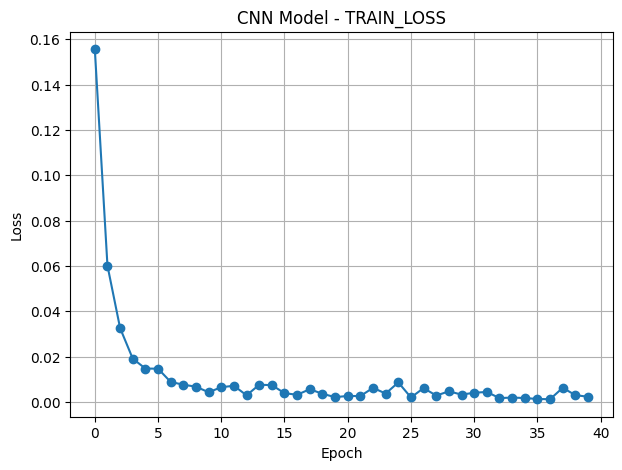

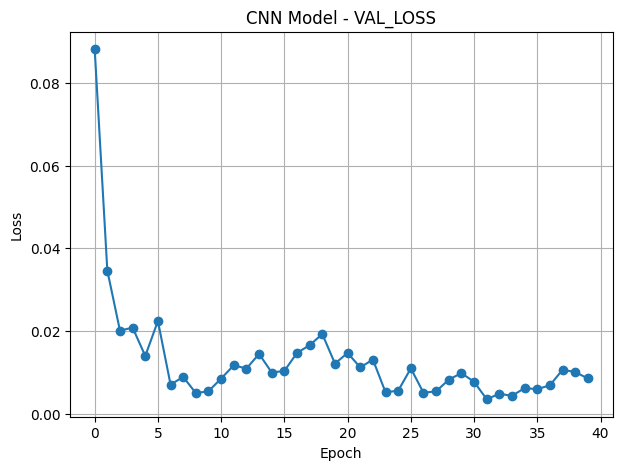

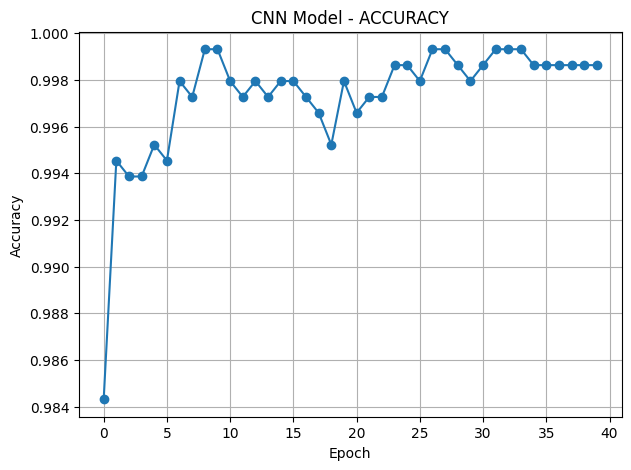

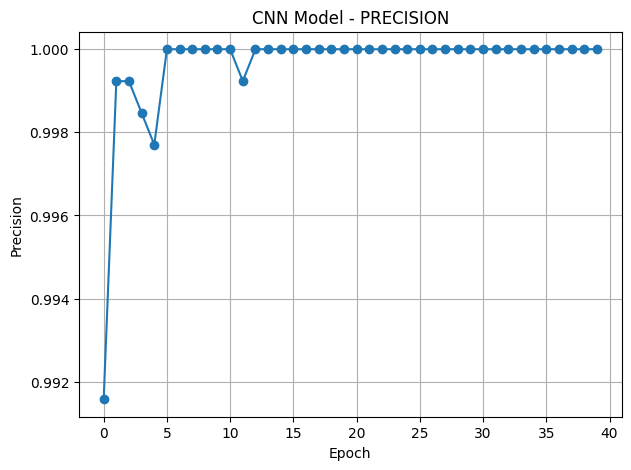

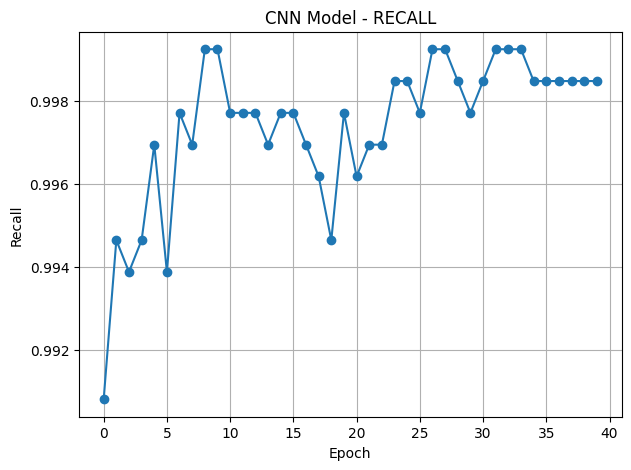

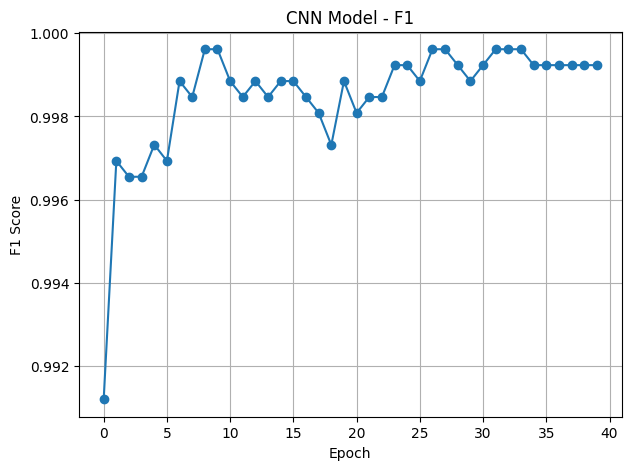

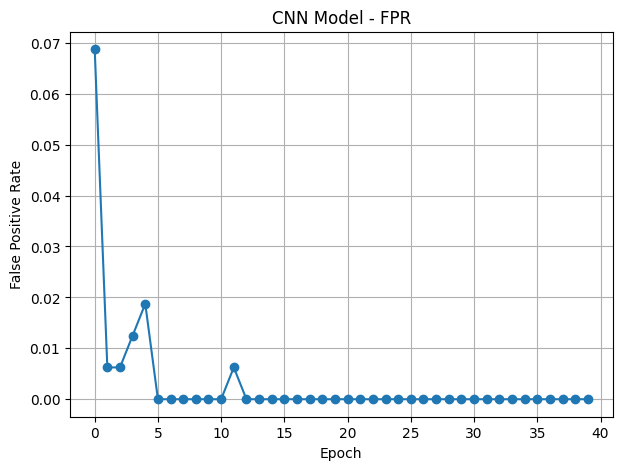

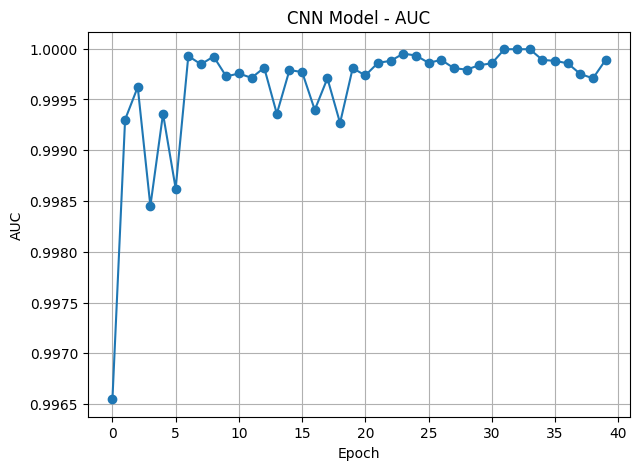

In [16]:
# ======================================================
# Plot All Curves
# ======================================================
def plot_metric(name, ylabel):
    plt.figure(figsize=(7, 5))
    plt.plot(history[name], marker='o')
    plt.title(f"CNN Model - {name.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

plot_metric("train_loss", "Loss")
plot_metric("val_loss", "Loss")
plot_metric("accuracy", "Accuracy")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")
plot_metric("f1", "F1 Score")
plot_metric("fpr", "False Positive Rate")
plot_metric("auc", "AUC")

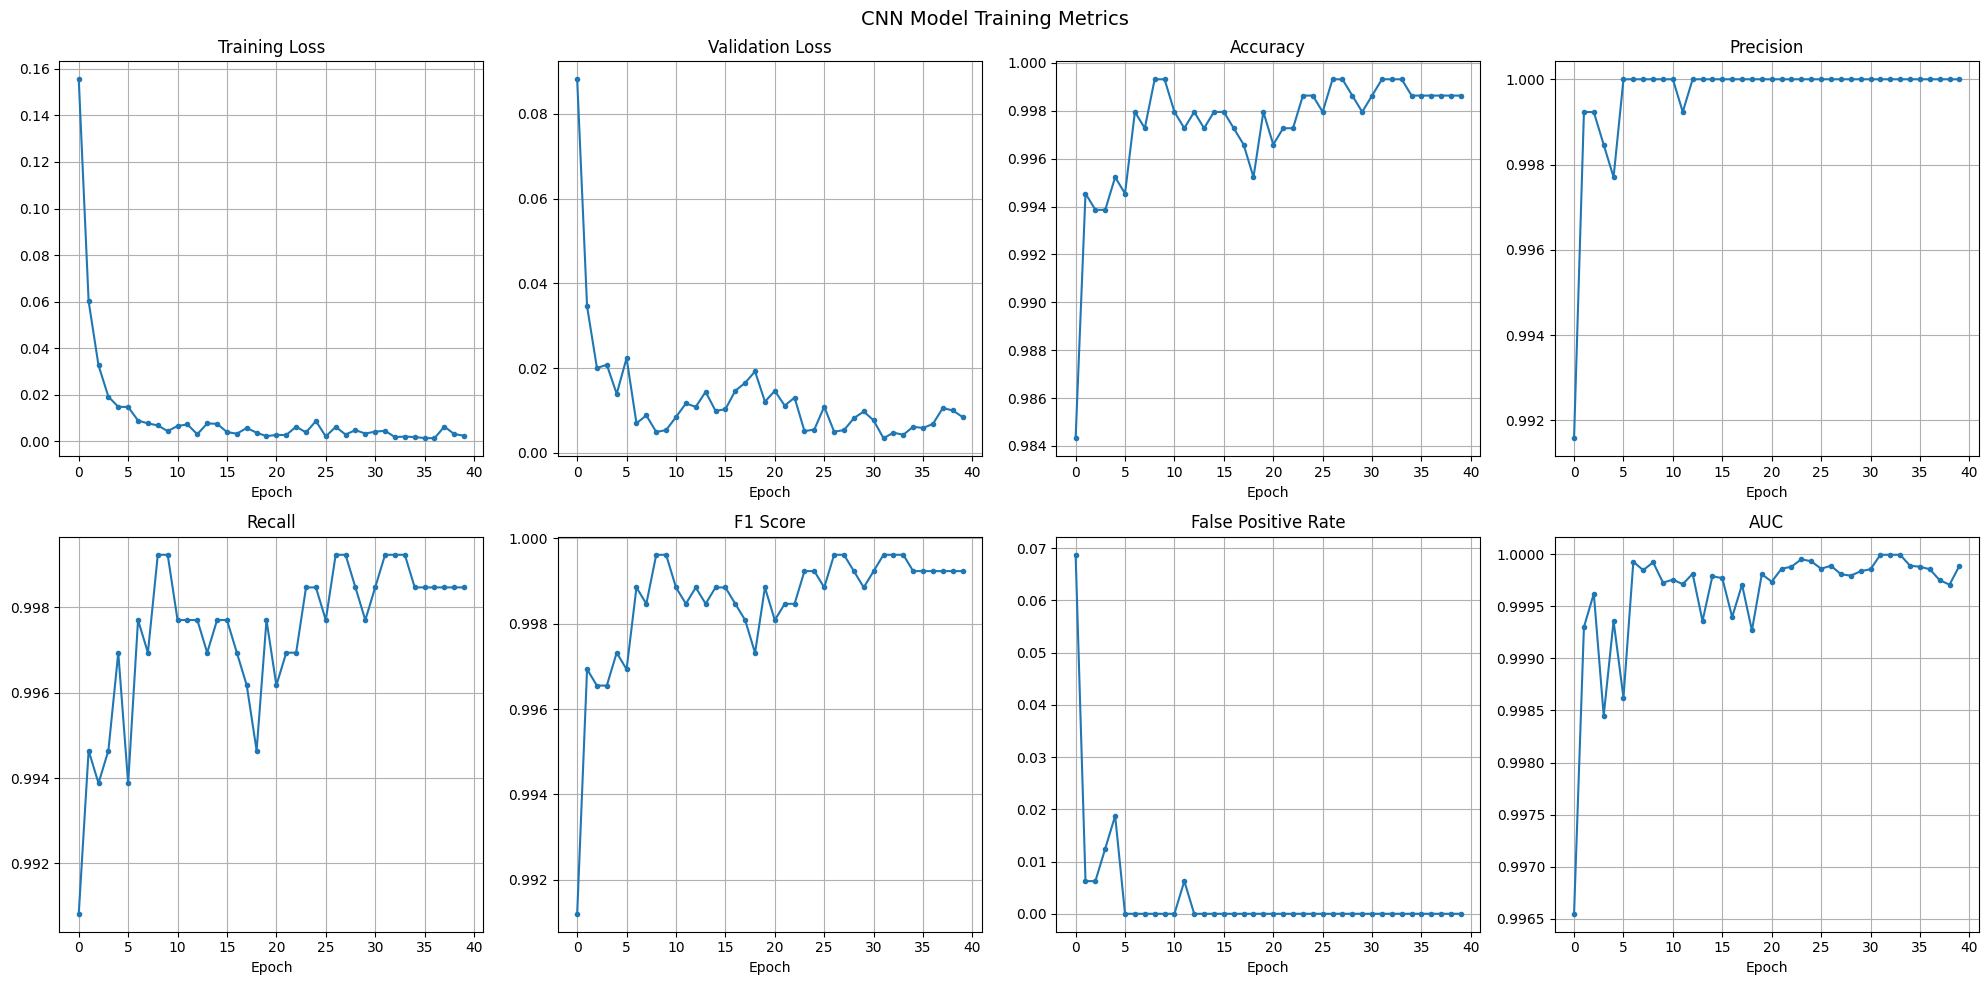

In [17]:
# ======================================================
# Combined Plots
# ======================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

metrics = ["train_loss", "val_loss", "accuracy", "precision", 
           "recall", "f1", "fpr", "auc"]
titles = ["Training Loss", "Validation Loss", "Accuracy", "Precision",
          "Recall", "F1 Score", "False Positive Rate", "AUC"]

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    ax.plot(history[metric], marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True)

plt.suptitle("CNN Model Training Metrics", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
min_values = scaler.data_min_.tolist()
max_values = scaler.data_max_.tolist()

In [19]:
import json

# Create a dictionary to hold the parameters
scaling_data = {
    "feature_min": min_values,
    "feature_max": max_values
}

# Define the output file name
output_file = "scaling_parameters_cnn.json"

# Save the dictionary to a JSON file
try:
    with open(output_file, 'w') as f:
        json.dump(scaling_data, f, indent=4)
    print(f"Successfully saved scaling parameters to {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully saved scaling parameters to scaling_parameters_cnn.json


In [20]:
# ======================================================
# Save PyTorch Model
# ======================================================
torch.save(model.state_dict(), "fbsdetector_cnn.pth")
print("PyTorch model saved to fbsdetector_cnn.pth")

PyTorch model saved to fbsdetector_cnn.pth


In [21]:
import torch
from torch.export import export
from executorch.exir import to_edge_transform_and_lower

# --- Configuration (Matching your data shapes) ---
SEQUENCE_LENGTH = WINDOW_SIZE
FEATURE_DIM = X_train_scaled.shape[2]
OUTPUT_PTE_FILE = "fbsdetector_cnn_generic_arm64.pte"

print("--- Starting ExecuTorch Export for Generic ARM64 (Core Kernels) ---")

# 1. Prepare the Model
model.to("cpu")
model.eval()

# 2. Create Example Inputs - Note: CNN expects (batch, channels, seq_length)
example_inputs = (torch.randn(1, FEATURE_DIM, SEQUENCE_LENGTH),)

try:
    # 3. Export (Capture the Graph)
    print("Capturing model graph...")
    exported_program = export(model, example_inputs)

    # 4. Lower to Portable Kernels
    print("Lowering to core ExecuTorch kernels...")
    edge_program = to_edge_transform_and_lower(
        exported_program,
        partitioner=[]
    )

    # 5. Convert to ExecuTorch Program and Save
    executorch_program = edge_program.to_executorch()

    with open(OUTPUT_PTE_FILE, "wb") as f:
        f.write(executorch_program.buffer)

    print(f"Success! ExecuTorch file saved to: {OUTPUT_PTE_FILE}")

except Exception as e:
    print(f"Export failed: {e}")

Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.14.0         Please see GitHub issue #2919 for more info
W0121 14:42:19.140000 78966 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


--- Starting ExecuTorch Export for Generic ARM64 (Core Kernels) ---
Capturing model graph...
Lowering to core ExecuTorch kernels...
Success! ExecuTorch file saved to: fbsdetector_cnn_generic_arm64.pte


In [22]:
# ======================================================
# Final Model Summary
# ======================================================
print("="*50)
print("CNN MODEL TRAINING COMPLETE")
print("="*50)
print(f"Final Accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final Precision: {history['precision'][-1]:.4f}")
print(f"Final Recall: {history['recall'][-1]:.4f}")
print(f"Final F1 Score: {history['f1'][-1]:.4f}")
print(f"Final AUC: {history['auc'][-1]:.4f}")
print(f"Final FPR: {history['fpr'][-1]:.4f}")
print("="*50)

CNN MODEL TRAINING COMPLETE
Final Accuracy: 0.9986
Final Precision: 1.0000
Final Recall: 0.9985
Final F1 Score: 0.9992
Final AUC: 0.9999
Final FPR: 0.0000
